In [1]:
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import numpy as np

sys.path.insert(0,"/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/")

sys.path.insert(0,"/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages")

print(sys.path)

import torch
import os
import pickle
import einops

#import plenoptic as po

'''
from model.layers.encoder import *
from model.layers.decoder import *
from model.layers.processor import *
from model.layers.graph_net_block import *
'''
from model.data.dataloader_graphnet import *
from model.data.load_data import *
#from model.forecast import GraphSatelliteForecaster
from model.loss_functions import *
from model.evaluation import *

import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score
import time
from datetime import datetime
import json
import argparse

import random

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import timeit

['/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/lus/lfs1aip1/home/b5s/jeffc.b5s/miniforge3/envs/new_graphnet/lib/python312.zip', '/lus/lfs1aip1/home/b5s/jeffc.b5s/miniforge3/envs/new_graphnet/lib/python3.12', '/lus/lfs1aip1/home/b5s/jeffc.b5s/miniforge3/envs/new_graphnet/lib/python3.12/lib-dynload', '', '/lus/lfs1aip1/home/b5s/jeffc.b5s/miniforge3/envs/new_graphnet/lib/python3.12/site-packages']


<jemalloc>: Unsupported system page size


In [2]:
train_load_data= {
        "year": "2014",
        "freq": 50,
        "region": "SAHARA",
        "size": 50,
        "verbose": True,
        "met_args": {
            "met_levels": [
                3,
                15,
                21
            ]
        },
        "delete_outofdomain": False
    }



# Load config
with open("config.yml", "r") as f:
    config = yaml.safe_load(f)

# Select the environment you're using
env = "isambard_ai"
env_paths = config["data_paths"][env]

# Join paths
base_data_path = env_paths["base_data_path"]
fp_datadir = os.path.join(base_data_path, env_paths["fp_datadir"].lstrip("/"))
met_datadir = os.path.join(base_data_path, env_paths["met_datadir"].lstrip("/"))
topog_datadir = os.path.join(base_data_path, env_paths["topog_datadir"].lstrip("/"))
landcover_datadir = os.path.join(base_data_path, env_paths["landcover_datadir"].lstrip("/"))

shared_data_args = dict(
    load_everything=True,
    base_data_path=base_data_path,
    fp_datadir=fp_datadir,
    met_datadir=met_datadir,
    topog_args={
        "topog_path": topog_datadir,
        "landcover_path": landcover_datadir
    }
)

In [3]:
data = LoadSquareSatelliteData(**train_load_data, **shared_data_args)

---- LOADING FOOTPRINTS
Loading footprint data from /projects/b5s/data/fp_archive/SAHARA/*SAHARA*2014*.nc
reduced the number of datapoints by frequency 50
Loading 114 footprints
----- Cutting footprints to square of size 50
careful! We had to pad the footprints along the latitude dimension to extract size 50 (0 and 8 idxs on either side) Padding with nan
1 footprints were at least partially filled with nans because they were cutting outside of the footprint file domain (this is 0.88% of samples)
Padding was needed for the following number of footprints along each direction: {'N': 1, 'S': 0, 'E': 0, 'W': 0}

 ---- LOADING MET
Loading meteorology from /projects/b5s/data/met_archive/UM/SAHARA/NORTHAFRICA_Met_2014*.nc
----- Cutting met
calculated wind angle and/or speed from x_wind and y_wind

---- LOADING TOPOG
trying to load topography from /projects/b5s/data/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
----- Cutting topog
---- All done!


In [4]:

import json
file_name = 'parameter_template_train_small.json'
file_path = '/home/b5s/jeffc.b5s/graphnet_LPDM_emulator/parameter_files/'

print(file_name, file_path)


def write_to_file(message):
    with open(log_file_path, "a") as f:
        f.write(datetime.now().strftime("%d/%m/%y %H:%M:%S") + " " + message + "\n")
        f.flush()
        os.fsync(f.fileno())

def load_file(file_name, file_path):
    # file_path=False if no argument was passed to the parser
    if not file_path:
       file_path ="/user/work/ef17148/GCN/graphnet/graph_weather/train_satellite_files/"
    file_path = f"{file_path}{file_name}"
    try:
        with open(file_path, 'r') as file:
            if file_path.endswith('.json'):
                data = json.load(file)
            else:
                data = file.read()
                data = json.loads(data)
        return data
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return None
    except Exception as e:
        print(f"An error occurred while loading the file: {str(e)}")
        return None

parameters = load_file(file_name, file_path) 

parameter_template_train_small.json /home/b5s/jeffc.b5s/graphnet_LPDM_emulator/parameter_files/


In [ ]:
input_variables = parameters["variables"]

: 

In [ ]:
inputs, names = get_square_satellite_inputs(data, **input_variables, return_variable_names=True, return_asarray=True)


---Preparing met
extracting met at t-H for H in: [0, 6, 12]
calculated wind angle and/or speed from x_wind and y_wind
calculated wind angle and/or speed from x_wind and y_wind
3
current length: 114
Length after removing indeces: 113
Setting up variables with levels: ['x_wind', 'upward_air_velocity']
Setting up surface variables: ['atmosphere_boundary_layer_thickness', 'surface_air_pressure']
Setting up static variables: ['lat_coords', 'lon_coords', 'x_coords', 'y_coords', 'topog', 'landcover']
(2, 50, 50)
Coordinates:
  * time             (time) datetime64[ns] 2014-01-02T11:35:58.500000 ... 201...
  * lat              (lat) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * lon              (lon) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * landcover_level  (landcover_level) int64 0 1 2 3 4 5 6 7 8 9


In [ ]:
has_nan_inputs = np.isnan(inputs).any()

In [ ]:
has_nan_inputs

True

In [7]:
print(inputs.shape)

(22, 2500, 24)


In [8]:
print(names)

[{'var': 'x_wind', 'level': 3, 'time_delta': 0, 'type': 'met'}, {'var': 'x_wind', 'level': 15, 'time_delta': 0, 'type': 'met'}, {'var': 'x_wind', 'level': 3, 'time_delta': 6, 'type': 'met'}, {'var': 'x_wind', 'level': 15, 'time_delta': 6, 'type': 'met'}, {'var': 'x_wind', 'level': 3, 'time_delta': 12, 'type': 'met'}, {'var': 'x_wind', 'level': 15, 'time_delta': 12, 'type': 'met'}, {'var': 'upward_air_velocity', 'level': 3, 'time_delta': 0, 'type': 'met'}, {'var': 'upward_air_velocity', 'level': 15, 'time_delta': 0, 'type': 'met'}, {'var': 'upward_air_velocity', 'level': 3, 'time_delta': 6, 'type': 'met'}, {'var': 'upward_air_velocity', 'level': 15, 'time_delta': 6, 'type': 'met'}, {'var': 'upward_air_velocity', 'level': 3, 'time_delta': 12, 'type': 'met'}, {'var': 'upward_air_velocity', 'level': 15, 'time_delta': 12, 'type': 'met'}, {'var': 'atmosphere_boundary_layer_thickness', 'time_delta': 0, 'type': 'surface_met'}, {'var': 'atmosphere_boundary_layer_thickness', 'time_delta': 6, 'ty

In [21]:
import numpy as np
import pandas as pd

N, P, V = inputs.shape
H = W = int(np.sqrt(P))
assert H * W == P, "Middle dimension isn't a perfect square."

# NaN counts per variable and per sample
nan_mask = np.isnan(inputs)
nan_per_var = nan_mask.sum(axis=(0,1))          # shape (V,)
nan_per_sample = nan_mask.sum(axis=(1,2))       # shape (N,)

# Make readable tables
var_labels = [f"{i}: {d['var']}"
              + (f"@L{d['level']}" if 'level' in d else "")
              + (f"+{d['time_delta']}h" if 'time_delta' in d else "")
              + f" ({d['type']})"
              for i, d in enumerate(names)]

df_var = pd.DataFrame({"variable": var_labels, "nan_count": nan_per_var})
df_var = df_var.sort_values("nan_count", ascending=False).reset_index(drop=True)

df_sample = pd.DataFrame({"sample_idx": np.arange(N), "nan_count": nan_per_sample})
df_sample = df_sample.sort_values("nan_count", ascending=False).reset_index(drop=True)

print("Top variables by NaN count:")
print(df_var.head(10).to_string(index=False))
print("\nTop samples by NaN count:")
print(df_sample.head(10).to_string(index=False))


Top variables by NaN count:
                                                 variable  nan_count
                                    0: y_wind@L3+0h (met)        700
                                    2: y_wind@L3+6h (met)        700
                                   3: y_wind@L15+6h (met)        700
                                   4: y_wind@L3+12h (met)        700
                                  5: y_wind@L15+12h (met)        700
                                   1: y_wind@L15+0h (met)        700
               23: surface_air_pressure+12h (surface_met)          0
20: atmosphere_boundary_layer_thickness+12h (surface_met)          0
                21: surface_air_pressure+0h (surface_met)          0
                22: surface_air_pressure+6h (surface_met)          0

Top samples by NaN count:
 sample_idx  nan_count
          0        300
          9        300
         20        300
         18        300
         17        300
         16        300
         15        300
  

In [25]:
import numpy as np

V = inputs.shape[-1]
H = W = int(np.sqrt(inputs.shape[1]))

ywind_ids = [i for i, d in enumerate(names) if d['var'] == 'y_wind']
assert len(ywind_ids) == 6, f"Expected 6 y_wind slices, got {len(ywind_ids)}"


In [26]:
nan_mask_y = np.isnan(inputs[:, :, ywind_ids])   # (N, P, 6)
nan_mask_y_2d = nan_mask_y.reshape(-1, H, W, len(ywind_ids))  # (N, H, W, 6)

# Count NaNs per row/col across variables
row_counts = nan_mask_y_2d.sum(axis=(2,3))  # (N, H), max per row = W * 6 = 300
col_counts = nan_mask_y_2d.sum(axis=(1,3))  # (N, W), max per col = H * 6 = 300

N = inputs.shape[0]
for s in range(N):
    bad_rows = np.where(row_counts[s] == W * len(ywind_ids))[0]
    bad_cols = np.where(col_counts[s] == H * len(ywind_ids))[0]
    if bad_rows.size or bad_cols.size:
        print(f"Sample {s}: full-NaN y_wind rows={bad_rows.tolist()} cols={bad_cols.tolist()}")


Sample 0: full-NaN y_wind rows=[23] cols=[]
Sample 1: full-NaN y_wind rows=[43] cols=[]
Sample 3: full-NaN y_wind rows=[21] cols=[]
Sample 7: full-NaN y_wind rows=[9] cols=[]
Sample 8: full-NaN y_wind rows=[25] cols=[]
Sample 9: full-NaN y_wind rows=[45] cols=[]
Sample 11: full-NaN y_wind rows=[43] cols=[]
Sample 13: full-NaN y_wind rows=[45] cols=[]
Sample 15: full-NaN y_wind rows=[44] cols=[]
Sample 16: full-NaN y_wind rows=[43] cols=[]
Sample 17: full-NaN y_wind rows=[43] cols=[]
Sample 18: full-NaN y_wind rows=[43] cols=[]
Sample 20: full-NaN y_wind rows=[4] cols=[]
Sample 21: full-NaN y_wind rows=[34] cols=[]


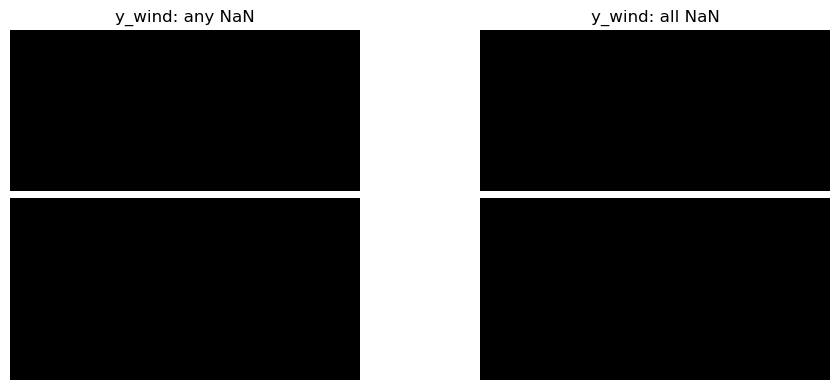

In [27]:
import matplotlib.pyplot as plt

sample = 0  # pick one from your "300" list
any_nan = nan_mask_y_2d[sample].any(axis=2)     # (H, W): any of the 6 y_wind is NaN
all_nan = nan_mask_y_2d[sample].all(axis=2)     # (H, W): all 6 y_wind are NaN

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(any_nan, cmap="gray"); plt.title("y_wind: any NaN"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(all_nan, cmap="gray"); plt.title("y_wind: all NaN"); plt.axis("off")
plt.tight_layout(); plt.show()


In [28]:
# Indices of static lat/lon layers
var2idx = {d['var']: i for i,d in enumerate(names)}
lat_idx = var2idx.get('lat_coords')
lon_idx = var2idx.get('lon_coords')

lat_grid = inputs[0, :, lat_idx].reshape(H, W) if lat_idx is not None else None
lon_grid = inputs[0, :, lon_idx].reshape(H, W) if lon_idx is not None else None

def report_latlon_for_sample(s):
    br = np.where(row_counts[s] == W * len(ywind_ids))[0]
    bc = np.where(col_counts[s] == H * len(ywind_ids))[0]
    if br.size and lat_grid is not None:
        r = br[0]
        print(f"Sample {s}: full-NaN row {r}, lat range ≈ {lat_grid[r,:].min():.4f} to {lat_grid[r,:].max():.4f}")
    if bc.size and lon_grid is not None:
        c = bc[0]
        print(f"Sample {s}: full-NaN col {c}, lon range ≈ {lon_grid[:,c].min():.4f} to {lon_grid[:,c].max():.4f}")

# run for the first few affected samples (replace with your indices)
for s in [0,1,9,11,13,15,16,17,18,20]:
    report_latlon_for_sample(s)


Sample 0: full-NaN row 23, lat range ≈ 25.0140 to 25.0140
Sample 1: full-NaN row 43, lat range ≈ 29.6940 to 29.6940
Sample 9: full-NaN row 45, lat range ≈ 30.1620 to 30.1620
Sample 11: full-NaN row 43, lat range ≈ 29.6940 to 29.6940
Sample 13: full-NaN row 45, lat range ≈ 30.1620 to 30.1620
Sample 15: full-NaN row 44, lat range ≈ 29.9280 to 29.9280
Sample 16: full-NaN row 43, lat range ≈ 29.6940 to 29.6940
Sample 17: full-NaN row 43, lat range ≈ 29.6940 to 29.6940
Sample 18: full-NaN row 43, lat range ≈ 29.6940 to 29.6940
Sample 20: full-NaN row 4, lat range ≈ 20.5680 to 20.5680


In [29]:
xwind_ids = [i for i,d in enumerate(names) if d['var']=='x_wind']
xm = np.isnan(inputs[:,:,xwind_ids]).reshape(-1,H,W,len(xwind_ids)).sum(axis=(2,3))
print("Any full-NaN x_wind rows? ", [s for s in range(N) if (xm[s]==W*len(xwind_ids)).any()])


Any full-NaN x_wind rows?  []


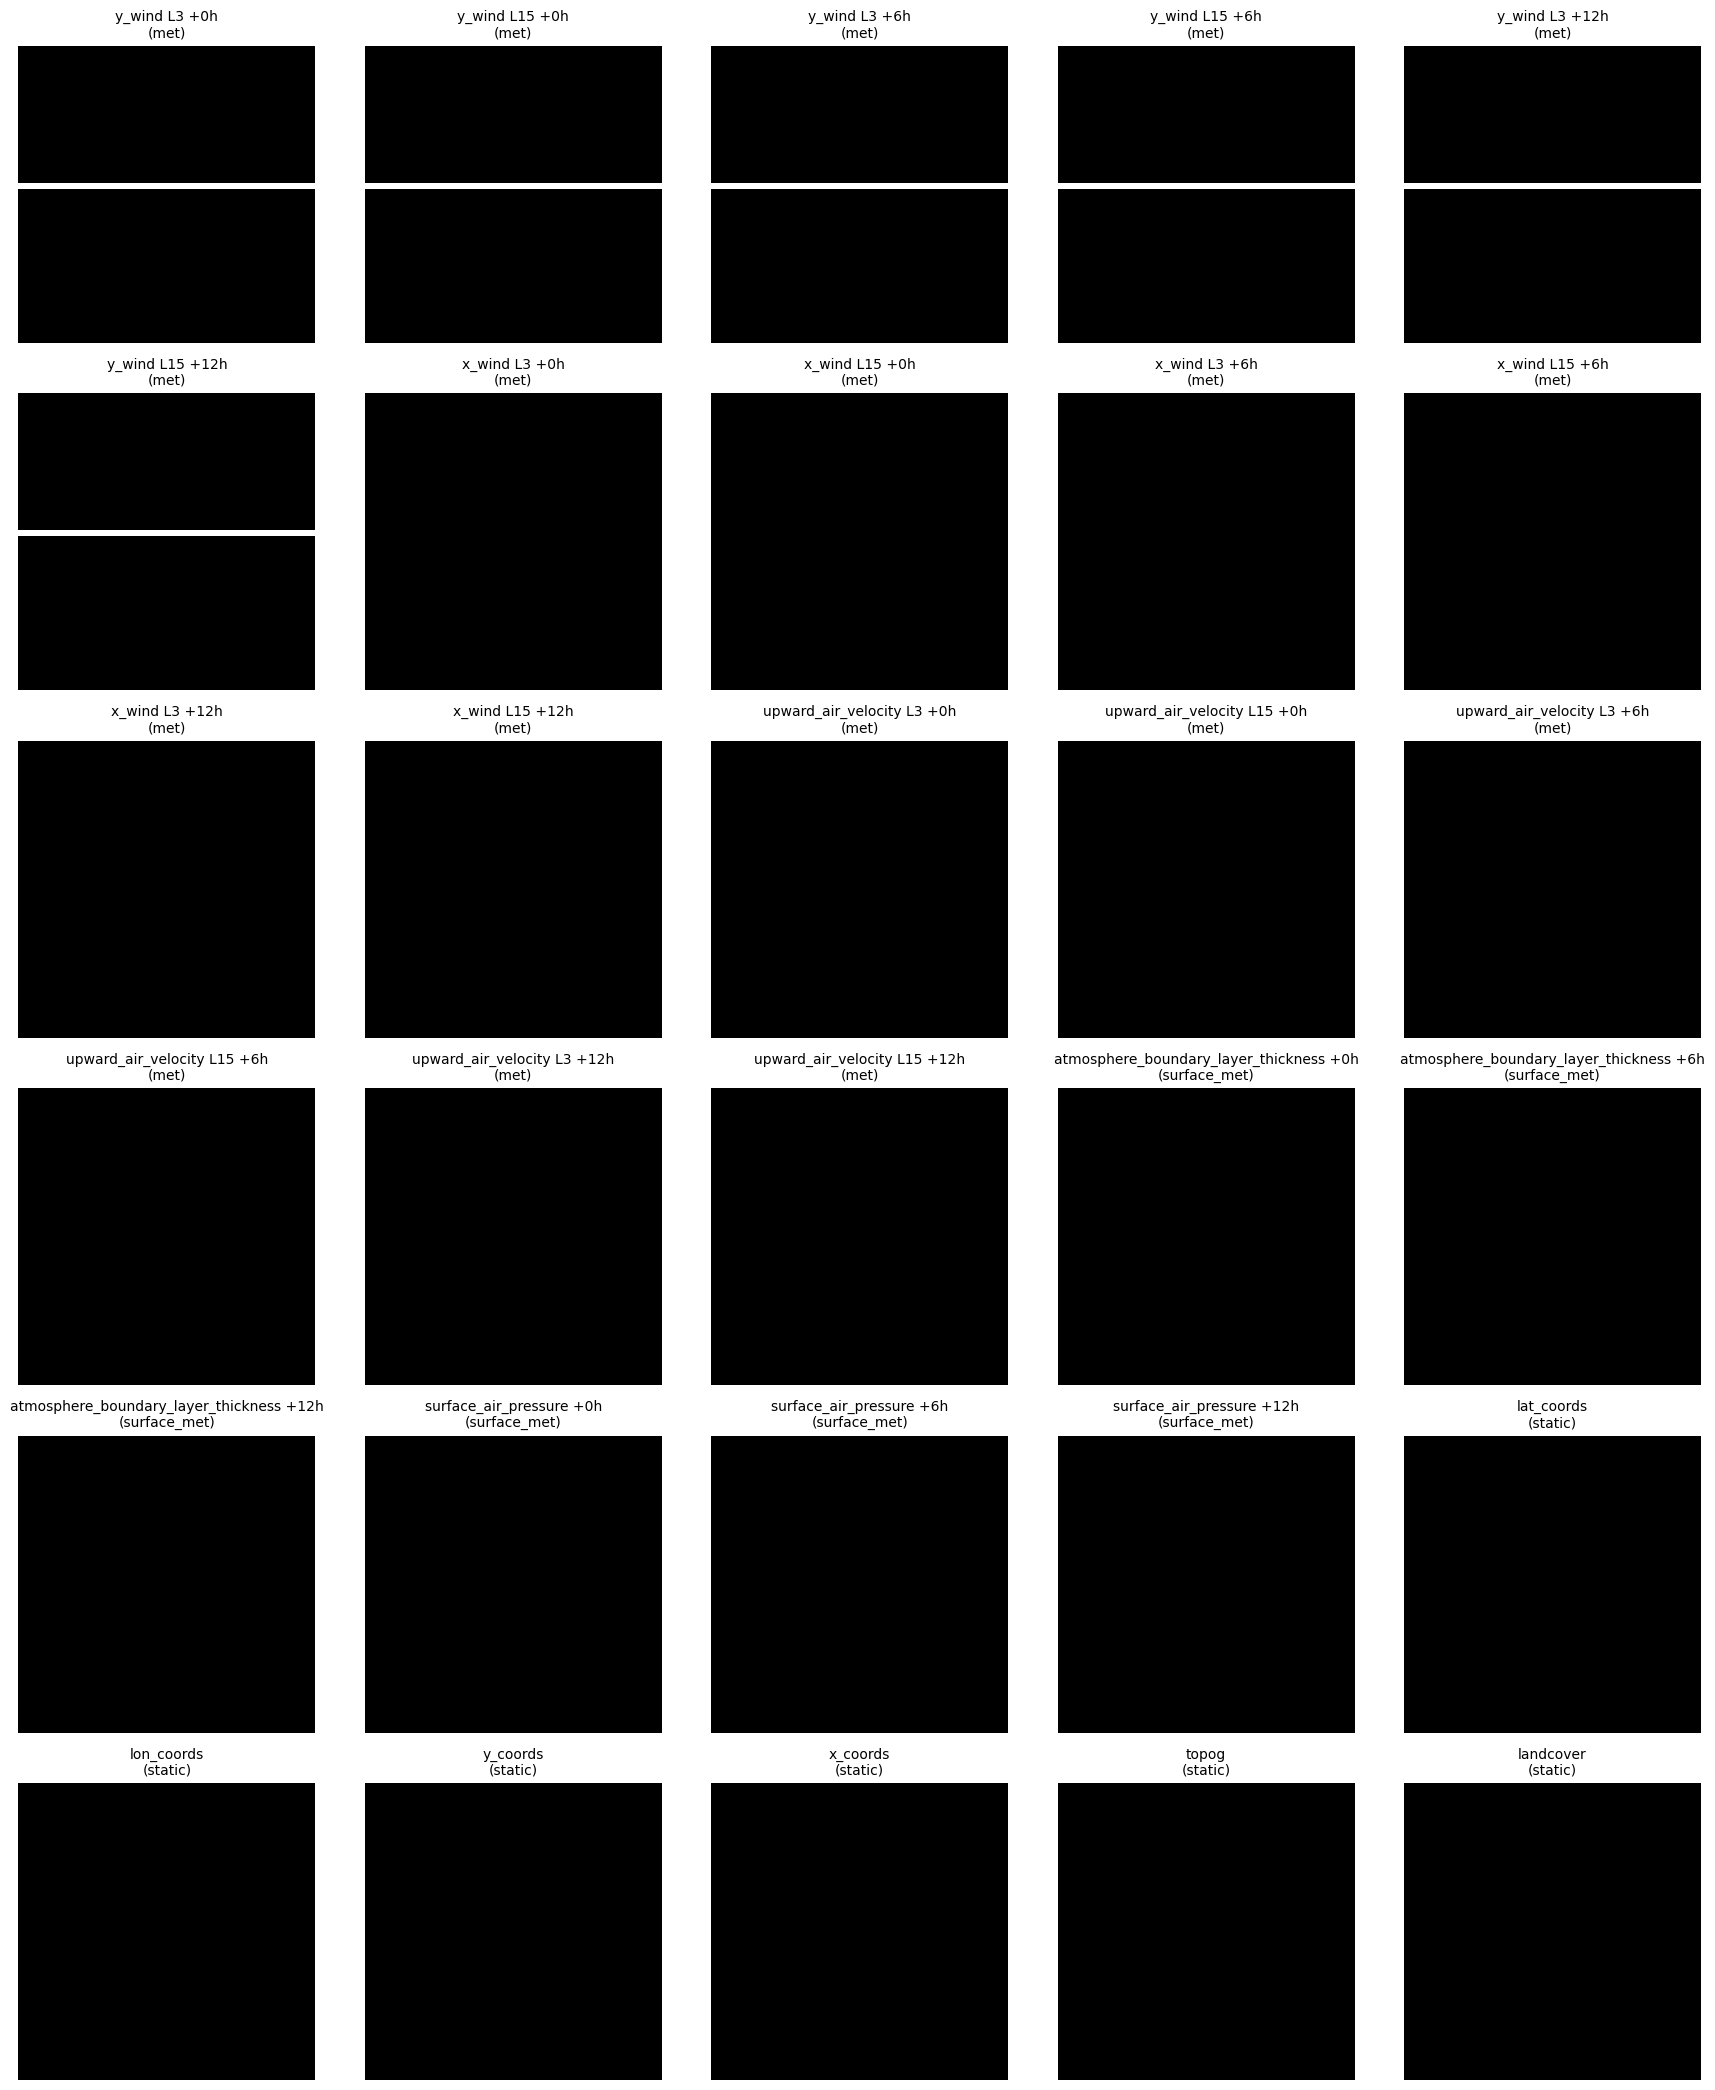

In [22]:
import matplotlib.pyplot as plt

sample = 0  # change if needed
vars_to_show = list(range(V))  # or pick a subset, e.g., [0,1,6,7,12,13,18,21,25,26,29]

cols = 5
rows = int(np.ceil(len(vars_to_show)/cols))
plt.figure(figsize=(3.5*cols, 3.5*rows))

for j, vidx in enumerate(vars_to_show, start=1):
    mask = np.isnan(inputs[sample, :, vidx]).reshape(H, W)
    plt.subplot(rows, cols, j)
    plt.imshow(mask, cmap="gray")
    d = names[vidx]
    title = f"{d['var']}"
    if 'level' in d: title += f" L{d['level']}"
    if 'time_delta' in d: title += f" +{d['time_delta']}h"
    title += f"\n({d['type']})"
    plt.title(title, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [23]:
nan_indices = np.argwhere(nan_mask)  # rows: [sample, pixel, var]
# Look at a few
for s, p, v in nan_indices[:20]:
    y, x = divmod(p, W)
    d = names[v]
    print(f"Sample {s}, Var={d['var']}, Level={d.get('level')}, Δt={d.get('time_delta')}h,"
          f" Type={d['type']}, Pixel(y={y}, x={x})")


Sample 0, Var=y_wind, Level=3, Δt=0h, Type=met, Pixel(y=23, x=0)
Sample 0, Var=y_wind, Level=15, Δt=0h, Type=met, Pixel(y=23, x=0)
Sample 0, Var=y_wind, Level=3, Δt=6h, Type=met, Pixel(y=23, x=0)
Sample 0, Var=y_wind, Level=15, Δt=6h, Type=met, Pixel(y=23, x=0)
Sample 0, Var=y_wind, Level=3, Δt=12h, Type=met, Pixel(y=23, x=0)
Sample 0, Var=y_wind, Level=15, Δt=12h, Type=met, Pixel(y=23, x=0)
Sample 0, Var=y_wind, Level=3, Δt=0h, Type=met, Pixel(y=23, x=1)
Sample 0, Var=y_wind, Level=15, Δt=0h, Type=met, Pixel(y=23, x=1)
Sample 0, Var=y_wind, Level=3, Δt=6h, Type=met, Pixel(y=23, x=1)
Sample 0, Var=y_wind, Level=15, Δt=6h, Type=met, Pixel(y=23, x=1)
Sample 0, Var=y_wind, Level=3, Δt=12h, Type=met, Pixel(y=23, x=1)
Sample 0, Var=y_wind, Level=15, Δt=12h, Type=met, Pixel(y=23, x=1)
Sample 0, Var=y_wind, Level=3, Δt=0h, Type=met, Pixel(y=23, x=2)
Sample 0, Var=y_wind, Level=15, Δt=0h, Type=met, Pixel(y=23, x=2)
Sample 0, Var=y_wind, Level=3, Δt=6h, Type=met, Pixel(y=23, x=2)
Sample 0, Var=

In [24]:
# Find indices of static coordinate variables
var2idx = {d['var']: i for i, d in enumerate(names)}

lat_idx = var2idx.get('lat_coords')
lon_idx = var2idx.get('lon_coords')

# These static layers are usually identical across samples; take sample 0.
lat_grid = inputs[0, :, lat_idx].reshape(H, W) if lat_idx is not None else None
lon_grid = inputs[0, :, lon_idx].reshape(H, W) if lon_idx is not None else None

# Example: print lat/lon for first few NaNs
count = 0
for s, p, v in nan_indices:
    if count >= 20:
        break
    y, x = divmod(p, W)
    d = names[v]
    lat_str = f"{lat_grid[y, x]:.4f}" if lat_grid is not None else "NA"
    lon_str = f"{lon_grid[y, x]:.4f}" if lon_grid is not None else "NA"
    print(f"Sample {s}, {d['var']}"
          + (f" L{d['level']}" if 'level' in d else "")
          + (f" +{d['time_delta']}h" if 'time_delta' in d else "")
          + f" ({d['type']}), y={y}, x={x}, lat={lat_str}, lon={lon_str}")
    count += 1


Sample 0, y_wind L3 +0h (met), y=23, x=0, lat=25.0140, lon=14.0640
Sample 0, y_wind L15 +0h (met), y=23, x=0, lat=25.0140, lon=14.0640
Sample 0, y_wind L3 +6h (met), y=23, x=0, lat=25.0140, lon=14.0640
Sample 0, y_wind L15 +6h (met), y=23, x=0, lat=25.0140, lon=14.0640
Sample 0, y_wind L3 +12h (met), y=23, x=0, lat=25.0140, lon=14.0640
Sample 0, y_wind L15 +12h (met), y=23, x=0, lat=25.0140, lon=14.0640
Sample 0, y_wind L3 +0h (met), y=23, x=1, lat=25.0140, lon=14.4160
Sample 0, y_wind L15 +0h (met), y=23, x=1, lat=25.0140, lon=14.4160
Sample 0, y_wind L3 +6h (met), y=23, x=1, lat=25.0140, lon=14.4160
Sample 0, y_wind L15 +6h (met), y=23, x=1, lat=25.0140, lon=14.4160
Sample 0, y_wind L3 +12h (met), y=23, x=1, lat=25.0140, lon=14.4160
Sample 0, y_wind L15 +12h (met), y=23, x=1, lat=25.0140, lon=14.4160
Sample 0, y_wind L3 +0h (met), y=23, x=2, lat=25.0140, lon=14.7680
Sample 0, y_wind L15 +0h (met), y=23, x=2, lat=25.0140, lon=14.7680
Sample 0, y_wind L3 +6h (met), y=23, x=2, lat=25.01

In [18]:
nan_indices_train = np.argwhere(np.isnan(inputs))
if nan_indices_train.size > 0:
    print(f"NaNs found in training set at indices: {nan_indices_train[:10]}")  # show just first 10 for now

NaNs found in training set at indices: [[   0 1150    0]
 [   0 1150    1]
 [   0 1150    2]
 [   0 1150    3]
 [   0 1150    4]
 [   0 1150    5]
 [   0 1151    0]
 [   0 1151    1]
 [   0 1151    2]
 [   0 1151    3]]


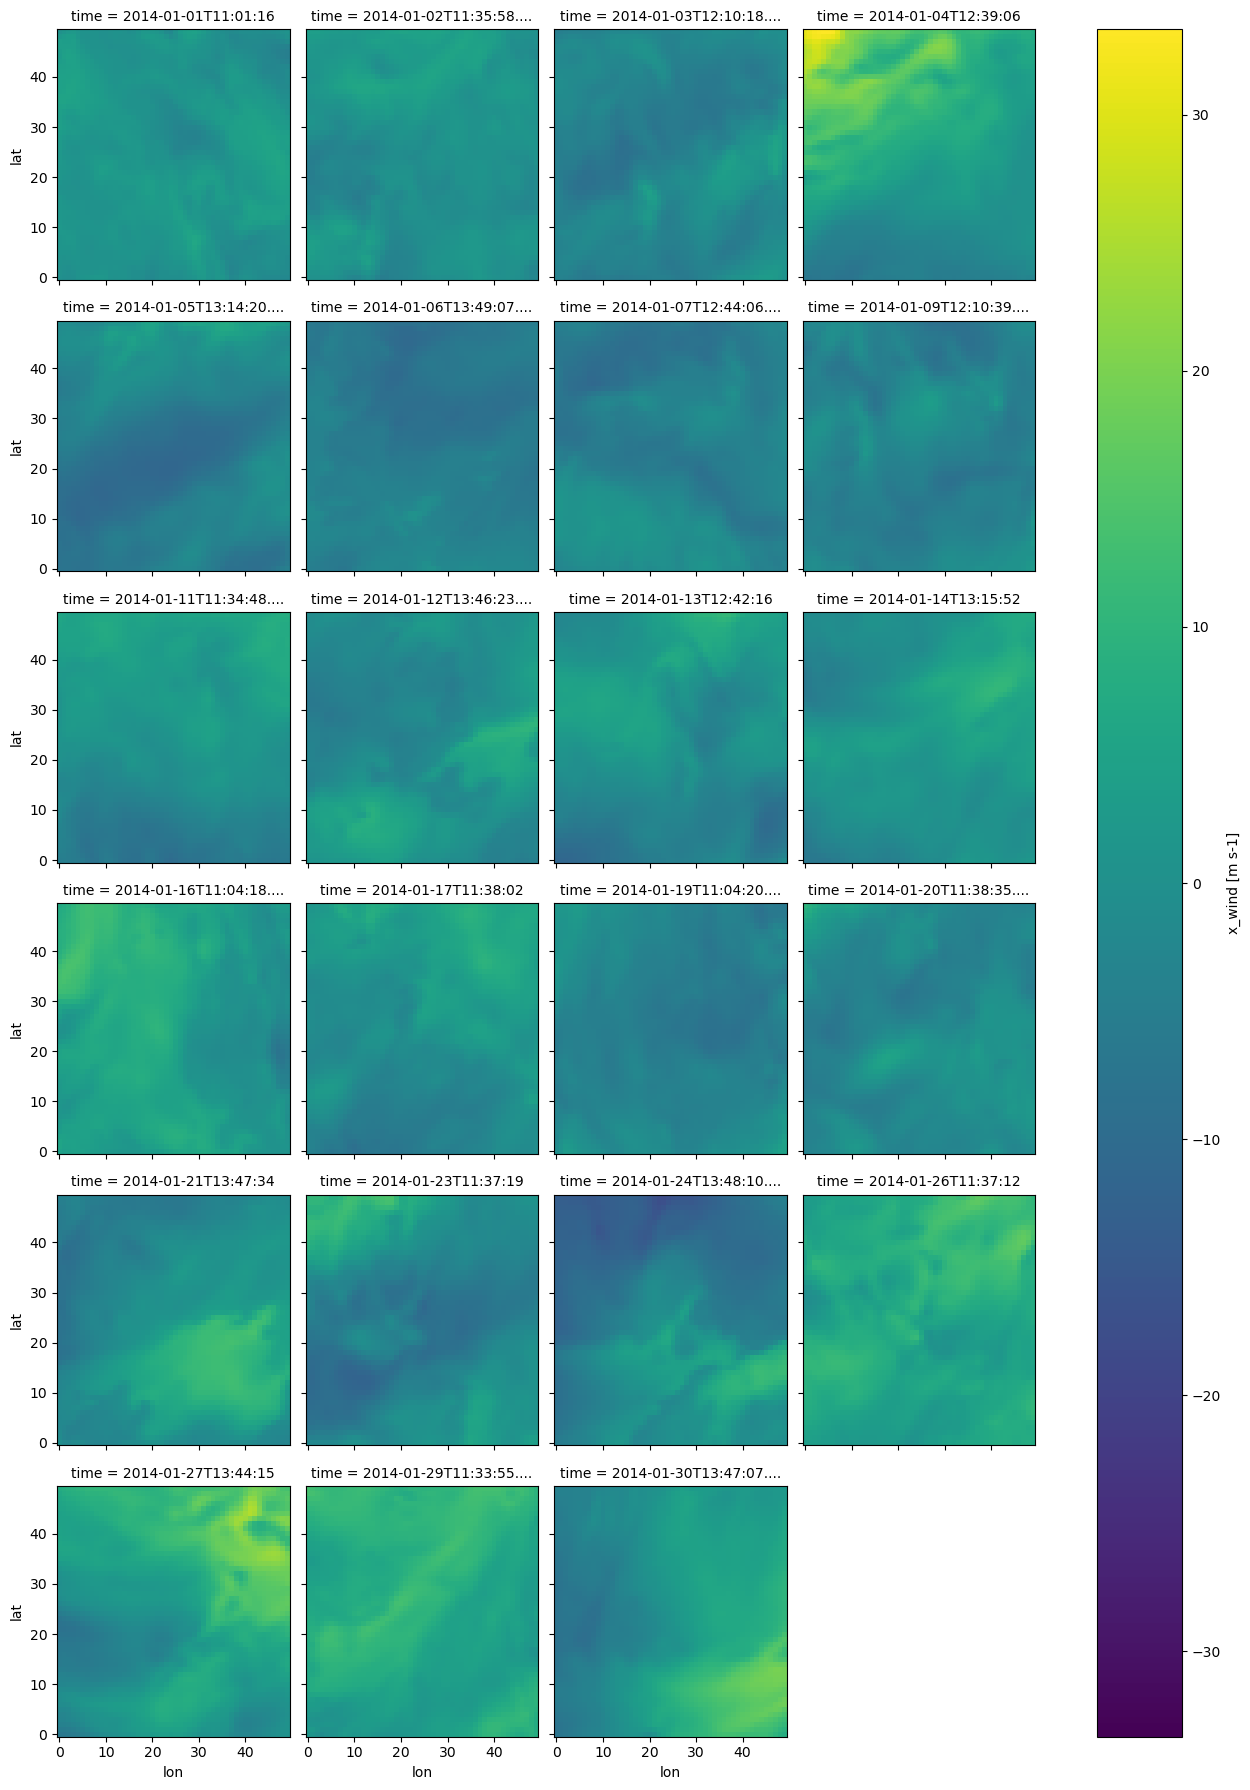

In [25]:
var.isel(levels=1).plot(x="lon", y="lat", col="time", col_wrap=4, cmap="viridis")
